In [1]:
# imports
import HTSeq
import numpy as np
import pandas as pd

from price2.cleavage_model import CleavageModel
from orf_activity_estimator import ORFActivityEstimator

from matplotlib import pyplot as plt


In [17]:
#gtf_path = 'data/ORF_NOISE_test.gtf'
gtf_path = 'data/reg_test.gtf'
#gtf_path = 'data/ad1 copy.gtf'

pl = np.array(pd.read_csv('data/upstream_cleavage_model', sep='\t', header=None)[0])
pr = np.array(pd.read_csv('data/downstream_cleavage_model', sep='\t', header=None)[0])


cm = CleavageModel(pl, pr, 0.1080613528993745)

orf_estimator = ORFActivityEstimator(
    cm, 
    reads_path='data/test.sam',
    gtf_path=gtf_path,
    maxiter=50,
    delta_cutoff=1,
    )



In [18]:
orf_estimator.fill_association_classes()

In [19]:
orf_estimator.run_orf_deconvolution(500)

break at iteration  51


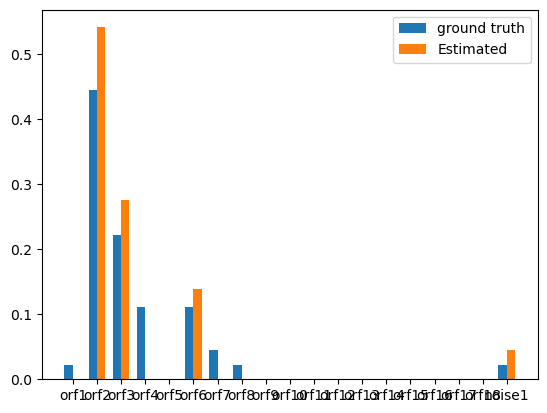

In [20]:
from fractions import Fraction

ground_truth = [float(Fraction(region.attr['activity'])) for region in HTSeq.GFF_Reader(gtf_path)]

estimated = [orf_estimator.regions[region_id].activity for region_id in orf_estimator.regions]
estimated = [x/sum(estimated) for x in estimated]

tick_labels = [region.attr['region_id'] for region in HTSeq.GFF_Reader(gtf_path)]

bar_width = 0.35

plt.bar([x-bar_width/2 for x in range(1,len(ground_truth)+1)], ground_truth, width=bar_width, label='ground truth')
plt.bar([x+bar_width/2 for x in range(1,len(ground_truth)+1)], estimated, width=bar_width, label='Estimated')
plt.legend()
plt.xticks([x for x in range(1,len(ground_truth)+1)], tick_labels)
pass

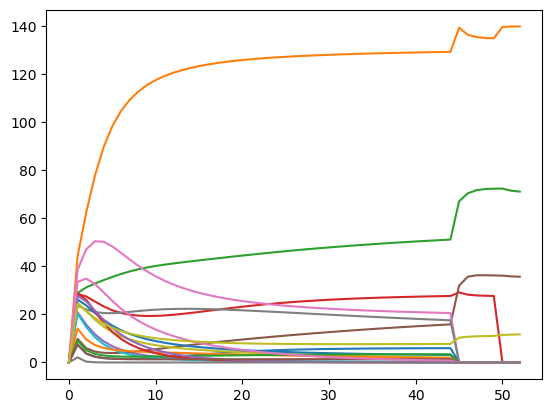

In [21]:
for region_id in orf_estimator.regions:
    plt.plot(orf_estimator.region_activities[region_id], label=region_id)
#plt.legend()

(0.001, 15)

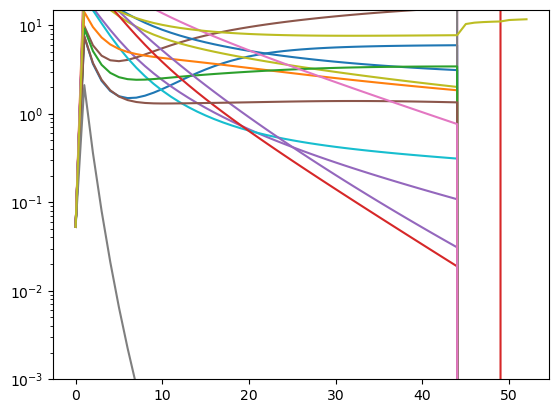

In [22]:
for region_id in orf_estimator.regions:
    plt.plot(orf_estimator.region_activities[region_id], label=region_id)
plt.yscale('log')
plt.ylim(1e-3,15)

In [8]:
#%load_ext line_profiler
#%lprun -f orf_estimator.run orf_estimator.run()

In [9]:
for region_id in orf_estimator.regions:
    print(f'{region_id}: {orf_estimator.regions[region_id].activity:.4f}')

orf1: 0.0000
orf2: 139.3907
orf3: 70.5199
orf4: 0.0000
orf5: 0.0000
orf6: 35.1981
orf7: 0.0000
orf8: 0.0000
orf9: 0.0000
orf10: 0.0000
orf11: 0.0000
orf12: 0.0000
orf13: 0.0000
orf14: 0.0000
orf15: 0.0000
orf16: 0.0000
orf17: 0.0000
orf18: 0.0000
noise1: 12.0518


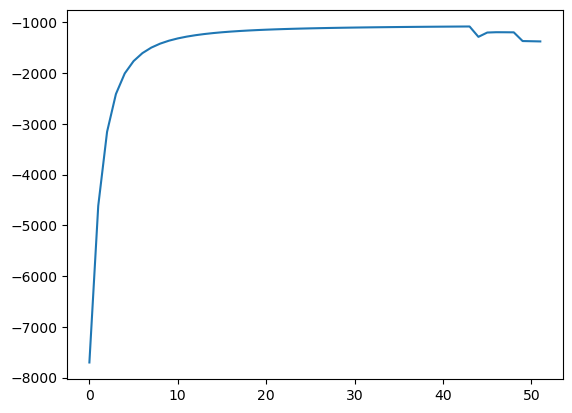

In [8]:
# incomplete data likelihood
plt.plot(orf_estimator.lls)

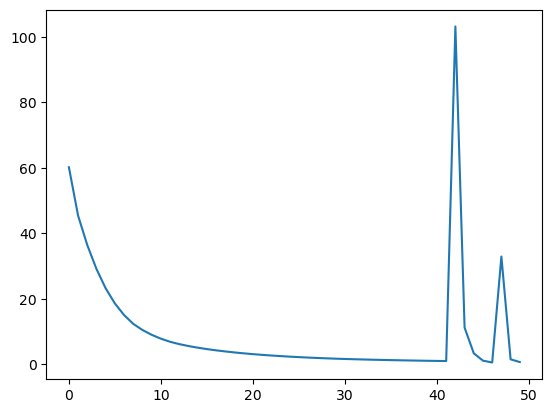

In [9]:
plt.plot(orf_estimator.activity_changes)